In [23]:
import pandas as pd
import os

# ==========================================
# 1. CARICAMENTO DATI
# ==========================================
files = {
    'mean': 'metrica1_stima_puntuale.csv',
    'low': 'metrica1_ci_inferiore.csv',
    'high': 'metrica1_ci_superiore.csv'
}

if not all(os.path.exists(f) for f in files.values()):
    print("ERRORE: Assicurati di avere i file metrica1_*.csv in /content/")
else:
    df_mean = pd.read_csv(files['mean'])
    df_low = pd.read_csv(files['low'])
    df_high = pd.read_csv(files['high'])

    # ==========================================
    # 2. FUNZIONE DI STAMPA AVANZATA
    # ==========================================
    def stampa_tabella_scenario(titolo, scenario_str, lista_scenari):
        print(f"\n\n=== {titolo} ===")
        print(f"Scenario: {scenario_str}")
        print("-" * 115)
        print(f"{'Descrizione (Variazione)':<30} | {'Coda U1 (Media)':<18} | {'Coda U2 (Media)':<18} | {'Coda TOTALE':<18} | {'Intervallo 95% (Tot)':<25}")
        print("-" * 115)

        for descrizione, params in lista_scenari:
            # Estrazione parametri
            cfg = params['Config']
            arr = params['m_arrivi']
            feed = params['p_feedback']
            ss1 = params['m_SS1']
            ss2 = params['m_SS2']
            q = params['q_prob_U1']

            mask = (
                (df_mean['Config'] == cfg) &
                (df_mean['m_arrivi'] == arr) &
                (df_mean['p_feedback'] == feed) &
                (df_mean['m_SS1'] == ss1) &
                (df_mean['m_SS2'] == ss2) &
                (df_mean['q_prob_U1'] == q)
            )

            if mask.sum() > 0:
                row_m = df_mean[mask].iloc[0]
                row_l = df_low[mask].iloc[0]
                row_h = df_high[mask].iloc[0]

                u1 = row_m['queueLenNode1_U1:timeavg']
                u2 = row_m['queueLenNode1_U2:timeavg']
                tot = row_m['CodaTotale_Nodo1']
                ci = f"[{row_l['CodaTotale_Nodo1']:.2f} - {row_h['CodaTotale_Nodo1']:.2f}]"

                print(f"{descrizione:<30} | {u1:<18.4f} | {u2:<18.4f} | {tot:<18.4f} | {ci:<25}")
            else:
                print(f"{descrizione:<30} | {'Dati mancanti':<50}")
        print("-" * 115)

    # ==========================================
    # 3. GENERAZIONE TABELLE
    # ==========================================

    # --- TABELLA A: CONFRONTO ARCHITETTURALE ---
    # Fisso: Arrivi=5.0, p=0.6, SS1=3.0, SS2=3.0, q=0.4
    scenari_A = [
        ("Config 1 (Ottimale)", {'Config': 'Config1', 'm_arrivi': 5.0, 'p_feedback': 0.6, 'm_SS1': 3.0, 'm_SS2': 3.0, 'q_prob_U1': 0.4}),
        ("Config 2 (Critica)",  {'Config': 'Config2', 'm_arrivi': 5.0, 'p_feedback': 0.6, 'm_SS1': 3.0, 'm_SS2': 3.0, 'q_prob_U1': 0.4})
    ]
    stampa_tabella_scenario(
        "TABELLA A: CONFRONTO ARCHITETTURALE (Ceteris Paribus)",
        "Arrivi=5.0, Feedback=0.6, SS1=3.0, SS2=3.0, q=0.4",
        scenari_A
    )

    # --- TABELLA B: STRESS TEST FEEDBACK (Il Collasso) ---
    # Fisso: Config 1, Arrivi=4.0, SS1=2.4 (Veloce), SS2=2.0, q=0.4
    scenari_B = [
        ("Feedback Basso (p=0.6)",   {'Config': 'Config1', 'm_arrivi': 4.0, 'p_feedback': 0.6, 'm_SS1': 2.4, 'm_SS2': 2.0, 'q_prob_U1': 0.4}),
        ("Feedback Medio (p=0.8)",   {'Config': 'Config1', 'm_arrivi': 4.0, 'p_feedback': 0.8, 'm_SS1': 2.4, 'm_SS2': 2.0, 'q_prob_U1': 0.4}),
        ("Feedback Critico (p=0.9)", {'Config': 'Config1', 'm_arrivi': 4.0, 'p_feedback': 0.9, 'm_SS1': 2.4, 'm_SS2': 2.0, 'q_prob_U1': 0.4})
    ]
    stampa_tabella_scenario(
        "TABELLA B: STRESS TEST FEEDBACK (Config 1, Alto Carico)",
        "Config=Config1, Arrivi=4.0, SS1=2.4, SS2=2.0, q=0.4",
        scenari_B
    )

    # --- TABELLA C: IMPATTO PRIORITÀ (Ingiustizia Sociale) ---
    # Fisso: Config 2, Arrivi=5.0, Feedback=0.6, SS1=3.0, SS2=3.0
    scenari_C = [
        ("Pochi VIP (q=0.4)",        {'Config': 'Config2', 'm_arrivi': 5.0, 'p_feedback': 0.6, 'm_SS1': 3.0, 'm_SS2': 3.0, 'q_prob_U1': 0.4}),
        ("Mix Equilibrato (q=0.6)",  {'Config': 'Config2', 'm_arrivi': 5.0, 'p_feedback': 0.6, 'm_SS1': 3.0, 'm_SS2': 3.0, 'q_prob_U1': 0.6}),
        ("Dominio VIP (q=0.8)",      {'Config': 'Config2', 'm_arrivi': 5.0, 'p_feedback': 0.6, 'm_SS1': 3.0, 'm_SS2': 3.0, 'q_prob_U1': 0.8})
    ]
    stampa_tabella_scenario(
        "TABELLA C: IMPATTO PRIORITÀ SU U2 (Config 2)",
        "Config=Config2, Arrivi=5.0, Feedback=0.6, SS1=3.0, SS2=3.0",
        scenari_C
    )

    # --- TABELLA D: SOLUZIONE HARDWARE (Scale-Up) ---
    # Fisso: Config 1, Arrivi=4.0, Feedback=0.8, SS2=2.0, q=0.4
    # Variabile: SS1 da 3.5 (Lento) a 2.4 (Veloce)
    scenari_D = [
        ("Server Lento (mu=3.5)",    {'Config': 'Config1', 'm_arrivi': 4.0, 'p_feedback': 0.8, 'm_SS1': 3.5, 'm_SS2': 2.0, 'q_prob_U1': 0.4}),
        ("Server Medio (mu=3.0)",    {'Config': 'Config1', 'm_arrivi': 4.0, 'p_feedback': 0.8, 'm_SS1': 3.0, 'm_SS2': 2.0, 'q_prob_U1': 0.4}),
        ("Server Veloce (mu=2.4)",   {'Config': 'Config1', 'm_arrivi': 4.0, 'p_feedback': 0.8, 'm_SS1': 2.4, 'm_SS2': 2.0, 'q_prob_U1': 0.4})
    ]
    stampa_tabella_scenario(
        "TABELLA D: SOLUZIONE TRAMITE SCALE-UP (Config 1, p=0.8)",
        "Config=Config1, Arrivi=4.0, Feedback=0.8, SS2=2.0, q=0.4",
        scenari_D
    )



=== TABELLA A: CONFRONTO ARCHITETTURALE (Ceteris Paribus) ===
Scenario: Arrivi=5.0, Feedback=0.6, SS1=3.0, SS2=3.0, q=0.4
-------------------------------------------------------------------------------------------------------------------
Descrizione (Variazione)       | Coda U1 (Media)    | Coda U2 (Media)    | Coda TOTALE        | Intervallo 95% (Tot)     
-------------------------------------------------------------------------------------------------------------------
Config 1 (Ottimale)            | 0.4414             | 1323.5298          | 1323.9713          | [1277.64 - 1370.30]      
Config 2 (Critica)             | 0.9277             | 3733.9979          | 3734.9256          | [3688.74 - 3781.11]      
-------------------------------------------------------------------------------------------------------------------


=== TABELLA B: STRESS TEST FEEDBACK (Config 1, Alto Carico) ===
Scenario: Config=Config1, Arrivi=4.0, SS1=2.4, SS2=2.0, q=0.4
----------------------------------

In [7]:
import pandas as pd
import os
import sys

# ==========================================
# 1. CARICAMENTO DATI (METRICA 1 FULL)
# ==========================================
files = {
    'mean': 'metrica1_stima_puntuale.csv',
    'low': 'metrica1_ci_inferiore.csv',
    'high': 'metrica1_ci_superiore.csv'
}

if not os.path.exists(files['mean']):
    print("ERRORE: Manca il file 'metrica1_stima_puntuale.csv'.")
else:
    df = pd.read_csv(files['mean'])
    df_l = pd.read_csv(files['low']) if os.path.exists(files['low']) else pd.DataFrame()
    df_h = pd.read_csv(files['high']) if os.path.exists(files['high']) else pd.DataFrame()

    print(f"Dati caricati. Modalità: ANALISI COMPLETA CODE (N1 + N2).")

    # ==========================================
    # 2. FUNZIONE INTERATTIVA
    # ==========================================
    def richiedi_parametro(nome_colonna, descrizione):
        valori_unici = sorted(df[nome_colonna].unique().tolist())
        print(f"\n--- {descrizione} ({nome_colonna}) ---")
        print(f"Opzioni: {valori_unici}")

        while True:
            user_input = input(f"Inserisci valore o premi INVIO per confrontarli tutti (*): ").strip()
            if user_input == "" or user_input == "*": return None

            try:
                tipo = type(valori_unici[0])
                val = tipo(user_input)
                if val in valori_unici: return val
                print(f"Errore: Valore non disponibile.")
            except: print("Errore formato.")

    # ==========================================
    # 3. CONFIGURAZIONE
    # ==========================================
    print("\n" + "="*80)
    print(" ANALISI CODE: DETTAGLIO COMPLETO PER NODO E CLASSE")
    print("="*80)

    filters = {}
    parametri = [
        ('Config', 'Configurazione'),
        ('m_arrivi', 'Tempo Medio Interarrivi'),
        ('p_feedback', 'Probabilità Feedback'),
        ('m_SS1', 'Tempo Medio Servizio SS1'),
        ('m_SS2', 'Tempo Medio Servizio SS2'),
        ('q_prob_U1', 'Probabilità Utente Prioritario')
    ]

    vars_scelte = []
    for col, desc in parametri:
        scelta = richiedi_parametro(col, desc)
        if scelta is not None: filters[col] = scelta
        else: vars_scelte.append(col)

    # ==========================================
    # 4. GENERAZIONE TABELLA GRANULARE
    # ==========================================
    print("\n" + "="*175)
    print(" RISULTATI: LUNGHEZZA CODE (Dettaglio Nodo 1 [U1, U2] e Nodo 2 [SS1, SS2])")

    mask = pd.Series([True] * len(df))
    for col, val in filters.items(): mask = mask & (df[col] == val)
    df_f = df[mask]

    if df_f.empty: print("NESSUN RISULTATO.")
    else:
        lbl = "Scenario" if not vars_scelte else " | ".join(vars_scelte)
        print("-" * 175)
        # Intestazione con TUTTE le colonne
        print(f"{lbl:<40} | {'N1_U1':<10} | {'N1_U2':<12} | {'N2_SS1':<12} | {'N2_SS2':<12} | {'TOT SISTEMA':<15} | {'CI 95% (N1 Tot)':<20}")
        print("-" * 175)

        for _, row in df_f.iterrows():
            desc = "Selezionato" if not vars_scelte else " ".join([f"{c}={row[c]:.1f}" if isinstance(row[c], float) else f"{c}={row[c]}" for c in vars_scelte])

            # --- ESTRAZIONE DATI ---
            # Nodo 1 (Diviso per classe)
            n1_u1 = row.get('queueLenNode1_U1:timeavg', 0)
            n1_u2 = row.get('queueLenNode1_U2:timeavg', 0)

            # Nodo 2 (Diviso per servente)
            n2_ss1 = row.get('queueLenSS1:timeavg', 0)
            n2_ss2 = row.get('queueLenSS2:timeavg', 0)

            # Totale Sistema
            tot_sistema = n1_u1 + n1_u2 + n2_ss1 + n2_ss2

            # CI (Mostriamo quello del Nodo 1 Totale come riferimento di stabilità primaria)
            ci_str = "[N/A]"
            if not df_l.empty:
                mask_ci = pd.Series([True] * len(df_l))
                for c in ['Config', 'm_arrivi', 'p_feedback', 'm_SS1', 'm_SS2', 'q_prob_U1']: mask_ci = mask_ci & (df_l[c] == row[c])

                if mask_ci.sum() > 0:
                    idx = df_l[mask_ci].index[0]
                    if 'CodaTotale_Nodo1' in df_l.columns:
                        l = df_l.loc[idx, 'CodaTotale_Nodo1']
                        h = df_h.loc[idx, 'CodaTotale_Nodo1']
                        ci_str = f"[{l:.1f}-{h:.1f}]"

            # Stampa formattata
            print(f"{desc:<40} | {n1_u1:<10.4f} | {n1_u2:<12.4f} | {n2_ss1:<12.4f} | {n2_ss2:<12.4f} | {tot_sistema:<15.4f} | {ci_str:<20}")
        print("-" * 175)

Dati caricati. Modalità: ANALISI COMPLETA CODE (N1 + N2).

 ANALISI CODE: DETTAGLIO COMPLETO PER NODO E CLASSE

--- Configurazione (Config) ---
Opzioni: ['Config1', 'Config2']
Inserisci valore o premi INVIO per confrontarli tutti (*): 

--- Tempo Medio Interarrivi (m_arrivi) ---
Opzioni: [4.0, 5.0, 6.0]
Inserisci valore o premi INVIO per confrontarli tutti (*): 6

--- Probabilità Feedback (p_feedback) ---
Opzioni: [0.6, 0.8, 0.9]
Inserisci valore o premi INVIO per confrontarli tutti (*): 

--- Tempo Medio Servizio SS1 (m_SS1) ---
Opzioni: [2.4, 3.0, 3.5]
Inserisci valore o premi INVIO per confrontarli tutti (*): 3

--- Tempo Medio Servizio SS2 (m_SS2) ---
Opzioni: [2.0, 3.0, 4.0]
Inserisci valore o premi INVIO per confrontarli tutti (*): 2

--- Probabilità Utente Prioritario (q_prob_U1) ---
Opzioni: [0.4, 0.6, 0.8]
Inserisci valore o premi INVIO per confrontarli tutti (*): 

 RISULTATI: LUNGHEZZA CODE (Dettaglio Nodo 1 [U1, U2] e Nodo 2 [SS1, SS2])
-------------------------------------

In [3]:
import pandas as pd
import os
import sys

# ==========================================
# 1. CARICAMENTO DATI (METRICA 2)
# ==========================================
# NOTA: Assicurati che i nomi dei file coincidano con quelli nella tua cartella
files = {
    'mean': 'metrica2_stima_puntuale_2.csv',       # O 'metrica2_stima_puntuale_2.csv' se hai quello
    'low': 'metrica2_ci_inferiore_2.csv',
    'high': 'metrica2_ci_superiore_2.csv'
}

# Controllo file
if not all(os.path.exists(f) for f in files.values()):
    print("ERRORE CRITICO: Mancano i file CSV della METRICA 2.")
    print(f"File cercati: {list(files.values())}")
else:
    df = pd.read_csv(files['mean'])
    df_l = pd.read_csv(files['low'])
    df_h = pd.read_csv(files['high'])

    print(f"Dati Metrica 2 caricati: {len(df)} righe totali.")

    # ==========================================
    # 2. FUNZIONE INTERATTIVA
    # ==========================================
    def richiedi_parametro(nome_colonna, descrizione):
        # .tolist() per pulire l'output da np.float64
        valori_unici = sorted(df[nome_colonna].unique().tolist())

        print(f"\n--- {descrizione} ({nome_colonna}) ---")
        print(f"Opzioni: {valori_unici}")

        while True:
            user_input = input(f"Inserisci valore o premi INVIO per confrontarli tutti (*): ").strip()

            if user_input == "" or user_input == "*":
                return None

            try:
                tipo_dato = type(valori_unici[0])
                valore_convertito = tipo_dato(user_input)

                if valore_convertito in valori_unici:
                    return valore_convertito
                else:
                    print(f"Errore: Valore '{valore_convertito}' non disponibile.")
            except ValueError:
                print("Errore: Formato non valido.")

    # ==========================================
    # 3. CONFIGURAZIONE
    # ==========================================
    print("\n" + "="*70)
    print(" ANALISI METRICA 2: TEMPO DI SOGGIORNO (Secondi)")
    print(" Istruzioni: Fissa i parametri, usa '*' per confrontare.")
    print("="*70)

    filters = {}
    parametri = [
        ('Config', 'Configurazione'),
        ('m_arrivi', 'Tempo Medio Interarrivi (m)'),
        ('p_feedback', 'Probabilità Feedback (p)'),
        ('m_SS1', 'Tempo Medio Servizio SS1'),
        ('m_SS2', 'Tempo Medio Servizio SS2'),
        ('q_prob_U1', 'Probabilità Utente Prioritario (q)')
    ]

    variabili_scelte = []
    for col, desc in parametri:
        scelta = richiedi_parametro(col, desc)
        if scelta is not None:
            filters[col] = scelta
        else:
            variabili_scelte.append(col)

    # ==========================================
    # 4. GENERAZIONE TABELLA (COLONNE AGGIORNATE)
    # ==========================================
    print("\n" + "="*100)
    print(" RISULTATI: TEMPO MEDIO NEL SISTEMA (Secondi)")

    mask = pd.Series([True] * len(df))
    for col, val in filters.items():
        mask = mask & (df[col] == val)

    df_filtered = df[mask]

    if df_filtered.empty:
        print("NESSUN RISULTATO TROVATO.")
    else:
        if not variabili_scelte:
            var_label = "Scenario Singolo"
        else:
            var_label = " | ".join(variabili_scelte)

        print("-" * 100)
        # Intestazioni specifiche per il Tempo
        print(f"{var_label:<40} | {'Tempo U1 (s)':<15} | {'Tempo U2 (s)':<15} | {'Intervallo 95% (U2)':<25}")
        print("-" * 100)

        for idx, row in df_filtered.iterrows():
            if not variabili_scelte:
                row_desc = "Configurazione Selezionata"
            else:
                parts = []
                for col in variabili_scelte:
                    val = row[col]
                    val_str = f"{val:.1f}" if isinstance(val, float) else str(val)
                    parts.append(f"{col}={val_str}")
                row_desc = " ".join(parts)

            # --- MODIFICA COLONNE ---
            # Qui cerchiamo i nomi tipici delle statistiche di tempo.
            # Se i tuoi CSV hanno nomi diversi (es. sojournTimeU1:mean), cambiali qui sotto.
            try:
                u1 = row['sojournTimeU1_stats_mean']
                u2 = row['sojournTimeU2_stats_mean']
            except KeyError:
                # Fallback se i nomi sono leggermente diversi (es. senza _stats)
                u1 = row.get('sojournTimeU1:mean', -1)
                u2 = row.get('sojournTimeU2:mean', -1)

            # CI per U2 (che è la metrica più critica)
            # Nota: Se hai una colonna "Totale" nel CSV, puoi aggiungerla.
            mask_ci = pd.Series([True] * len(df_l))
            for c in ['Config', 'm_arrivi', 'p_feedback', 'm_SS1', 'm_SS2', 'q_prob_U1']:
                mask_ci = mask_ci & (df_l[c] == row[c])

            if mask_ci.sum() > 0:
                idx_ci = df_l[mask_ci].index[0]
                # Qui prendiamo il CI di U2
                try:
                    val_low = df_l.loc[idx_ci, 'sojournTimeU2_stats_mean']
                    val_high = df_h.loc[idx_ci, 'sojournTimeU2_stats_mean']
                except KeyError:
                    val_low = df_l.loc[idx_ci, 'sojournTimeU2:mean']
                    val_high = df_h.loc[idx_ci, 'sojournTimeU2:mean']

                ci_str = f"[{val_low:.2f} - {val_high:.2f}]"
            else:
                ci_str = "[N/A]"

            print(f"{row_desc:<40} | {u1:<15.4f} | {u2:<15.4f} | {ci_str:<25}")

        print("-" * 100)

Dati Metrica 2 caricati: 486 righe totali.

 ANALISI METRICA 2: TEMPO DI SOGGIORNO (Secondi)
 Istruzioni: Fissa i parametri, usa '*' per confrontare.

--- Configurazione (Config) ---
Opzioni: ['Config1', 'Config2']
Inserisci valore o premi INVIO per confrontarli tutti (*): 

--- Tempo Medio Interarrivi (m) (m_arrivi) ---
Opzioni: [4.0, 5.0, 6.0]
Inserisci valore o premi INVIO per confrontarli tutti (*): 6

--- Probabilità Feedback (p) (p_feedback) ---
Opzioni: [0.6, 0.8, 0.9]
Inserisci valore o premi INVIO per confrontarli tutti (*): 

--- Tempo Medio Servizio SS1 (m_SS1) ---
Opzioni: [2.4, 3.0, 3.5]
Inserisci valore o premi INVIO per confrontarli tutti (*): 3

--- Tempo Medio Servizio SS2 (m_SS2) ---
Opzioni: [2.0, 3.0, 4.0]
Inserisci valore o premi INVIO per confrontarli tutti (*): 2

--- Probabilità Utente Prioritario (q) (q_prob_U1) ---
Opzioni: [0.4, 0.6, 0.8]
Inserisci valore o premi INVIO per confrontarli tutti (*): 

 RISULTATI: TEMPO MEDIO NEL SISTEMA (Secondi)
---------------

In [8]:
import pandas as pd
import os
import sys

# ==========================================
# 1. CARICAMENTO DATI (METRICA 3)
# ==========================================
files = {
    'mean': 'metrica3_stima_puntuale_2.csv',
    'low': 'metrica3_ci_inferiore_2.csv',
    'high': 'metrica3_ci_superiore_2.csv'
}

if not all(os.path.exists(f) for f in files.values()):
    print("ERRORE: Assicurati di avere i file CSV della metrica 3.")
else:
    df = pd.read_csv(files['mean'])
    df_l = pd.read_csv(files['low']) if os.path.exists(files['low']) else pd.DataFrame()
    df_h = pd.read_csv(files['high']) if os.path.exists(files['high']) else pd.DataFrame()

    # ==========================================
    # 2. FUNZIONE INTERATTIVA
    # ==========================================
    def richiedi_parametro(nome_colonna, descrizione):
        valori_unici = sorted(df[nome_colonna].unique().tolist())
        print(f"\n--- {descrizione} ({nome_colonna}) ---")
        print(f"Opzioni: {valori_unici}")
        while True:
            user_input = input(f"Inserisci valore o premi INVIO per confrontarli tutti (*): ").strip()
            if user_input == "" or user_input == "*": return None
            try:
                tipo = type(valori_unici[0])
                val = tipo(user_input)
                if val in valori_unici: return val
                print(f"Errore: Valore non disponibile.")
            except: print("Errore formato.")

    # ==========================================
    # 3. CONFIGURAZIONE
    # ==========================================
    print("\n" + "="*80)
    print(" METRICA 3 COMPLETA: MINIMI E MASSIMI (U1 e U2)")
    print("="*80)

    filters = {}
    parametri = [
        ('Config', 'Configurazione'),
        ('m_arrivi', 'Tempo Medio Interarrivi'),
        ('p_feedback', 'Probabilità Feedback'),
        ('m_SS1', 'Tempo Medio Servizio SS1'),
        ('m_SS2', 'Tempo Medio Servizio SS2'),
        ('q_prob_U1', 'Probabilità Utente Prioritario')
    ]

    vars_scelte = []
    for col, desc in parametri:
        scelta = richiedi_parametro(col, desc)
        if scelta is not None: filters[col] = scelta
        else: vars_scelte.append(col)

    # ==========================================
    # 4. GENERAZIONE TABELLA AGGIORNATA
    # ==========================================
    print("\n" + "="*145)
    print(" RISULTATI PERCENTILI (5% = Minimo, 95% = Massimo)")

    mask = pd.Series([True] * len(df))
    for col, val in filters.items(): mask = mask & (df[col] == val)
    df_f = df[mask]

    if df_f.empty: print("NESSUN RISULTATO.")
    else:
        lbl = "Scenario" if not vars_scelte else " | ".join(vars_scelte)
        print("-" * 145)
        # ORA INCLUDIAMO ANCHE U1 MIN
        print(f"{lbl:<40} | {'U1 Min':<12} | {'U1 Max':<12} | {'U2 Min':<15} | {'U2 Max':<15} | {'CI 95% (U2 Max)':<25}")
        print("-" * 145)

        for _, row in df_f.iterrows():
            desc = "Selezionato" if not vars_scelte else " ".join([f"{c}={row[c]:.1f}" if isinstance(row[c], float) else f"{c}={row[c]}" for c in vars_scelte])

            # Estrazione Completa
            u1_min = row.get('sojournTimeU1_vec:vector_Stima_Minimo_05perc', float('nan'))
            u1_max = row.get('sojournTimeU1_vec:vector_Stima_Massimo_95perc', float('nan'))
            u2_min = row.get('sojournTimeU2_vec:vector_Stima_Minimo_05perc', float('nan'))
            u2_max = row.get('sojournTimeU2_vec:vector_Stima_Massimo_95perc', float('nan'))

            # CI U2 Max
            ci_str = "[N/A]"
            if not df_l.empty:
                mask_ci = pd.Series([True] * len(df_l))
                for c in ['Config', 'm_arrivi', 'p_feedback', 'm_SS1', 'm_SS2', 'q_prob_U1']: mask_ci = mask_ci & (df_l[c] == row[c])
                if mask_ci.sum() > 0:
                    idx = df_l[mask_ci].index[0]
                    # Verifica il nome colonna nel CI (potrebbe essere uguale al mean)
                    col_target = 'sojournTimeU2_vec:vector_Stima_Massimo_95perc'
                    if col_target in df_l.columns:
                        ci_str = f"[{df_l.loc[idx, col_target]:.1f}-{df_h.loc[idx, col_target]:.1f}]"

            def f(v): return f"{v:.2f}" if pd.notna(v) else "NaN"
            print(f"{desc:<40} | {f(u1_min):<12} | {f(u1_max):<12} | {f(u2_min):<15} | {f(u2_max):<15} | {ci_str:<25}")
        print("-" * 145)


 METRICA 3 COMPLETA: MINIMI E MASSIMI (U1 e U2)

--- Configurazione (Config) ---
Opzioni: ['Config1', 'Config2']
Inserisci valore o premi INVIO per confrontarli tutti (*): 

--- Tempo Medio Interarrivi (m_arrivi) ---
Opzioni: [4.0, 5.0, 6.0]
Inserisci valore o premi INVIO per confrontarli tutti (*): 6

--- Probabilità Feedback (p_feedback) ---
Opzioni: [0.6, 0.8, 0.9]
Inserisci valore o premi INVIO per confrontarli tutti (*): 

--- Tempo Medio Servizio SS1 (m_SS1) ---
Opzioni: [2.4, 3.0, 3.5]
Inserisci valore o premi INVIO per confrontarli tutti (*): 3

--- Tempo Medio Servizio SS2 (m_SS2) ---
Opzioni: [2.0, 3.0, 4.0]
Inserisci valore o premi INVIO per confrontarli tutti (*): 2

--- Probabilità Utente Prioritario (q_prob_U1) ---
Opzioni: [0.4, 0.6, 0.8]
Inserisci valore o premi INVIO per confrontarli tutti (*): 

 RISULTATI PERCENTILI (5% = Minimo, 95% = Massimo)
---------------------------------------------------------------------------------------------------------------------------

In [9]:
import pandas as pd
import os
import sys

# ==========================================
# 1. CARICAMENTO DATI (METRICA 4)
# ==========================================
files = {
    'mean': 'metrica4_stima_puntuale_2.csv',
    'low': 'metrica4_ci_inferiore_2.csv',
    'high': 'metrica4_ci_superiore_2.csv'
}

if not all(os.path.exists(f) for f in files.values()):
    print("ERRORE CRITICO: Mancano i file CSV della Metrica 4.")
    print(f"File attesi: {list(files.values())}")
else:
    df = pd.read_csv(files['mean'])
    df_l = pd.read_csv(files['low'])
    df_h = pd.read_csv(files['high'])

    print(f"Dati Metrica 4 caricati: {len(df)} righe totali.")

    # ==========================================
    # 2. FUNZIONE INTERATTIVA
    # ==========================================
    def richiedi_parametro(nome_colonna, descrizione):
        # .tolist() per pulizia output
        valori_unici = sorted(df[nome_colonna].unique().tolist())

        print(f"\n--- {descrizione} ({nome_colonna}) ---")
        print(f"Opzioni: {valori_unici}")

        while True:
            user_input = input(f"Inserisci valore o premi INVIO per confrontarli tutti (*): ").strip()

            if user_input == "" or user_input == "*":
                return None

            try:
                tipo_dato = type(valori_unici[0])
                valore_convertito = tipo_dato(user_input)

                if valore_convertito in valori_unici:
                    return valore_convertito
                else:
                    print(f"Errore: Valore '{valore_convertito}' non disponibile.")
            except ValueError:
                print("Errore: Formato non valido.")

    # ==========================================
    # 3. CONFIGURAZIONE FILTRI
    # ==========================================
    print("\n" + "="*80)
    print(" ANALISI METRICA 4: VIOLAZIONE SOGLIA")
    print(" Istruzioni: Fissa i parametri, usa '*' per confrontare.")
    print("="*80)

    filters = {}
    parametri = [
        ('Config', 'Configurazione'),
        ('m_arrivi', 'Tempo Medio Interarrivi (m)'),
        ('p_feedback', 'Probabilità Feedback (p)'),
        ('m_SS1', 'Tempo Medio Servizio SS1'),
        ('m_SS2', 'Tempo Medio Servizio SS2'),
        ('q_prob_U1', 'Probabilità Utente Prioritario (q)')
    ]

    variabili_scelte = []
    for col, desc in parametri:
        scelta = richiedi_parametro(col, desc)
        if scelta is not None:
            filters[col] = scelta
        else:
            variabili_scelte.append(col)

    # ==========================================
    # 4. SCELTA DEL THRESHOLD (Nuova Sezione)
    # ==========================================
    print("\n--- Scelta Threshold (Soglia di Tempo) ---")
    print("Opzioni: [2, 3, 4]")
    while True:
        th_input = input("Inserisci soglia (2, 3, o 4): ").strip()
        if th_input in ['2', '3', '4']:
            # Costruiamo la stringa come appare nel CSV (es. "4.0s")
            threshold_str = f"{th_input}.0s"
            break
        else:
            print("Errore: Inserisci solo 2, 3 o 4.")

    # ==========================================
    # 5. GENERAZIONE TABELLA DINAMICA
    # ==========================================
    print("\n" + "="*120)
    print(f" RISULTATI: PROBABILITÀ P(T > {threshold_str})")
    print(" (Valori vicini a 1.0 indicano che quasi tutti gli utenti superano la soglia)")

    mask = pd.Series([True] * len(df))
    for col, val in filters.items():
        mask = mask & (df[col] == val)

    df_filtered = df[mask]

    if df_filtered.empty:
        print("NESSUN RISULTATO TROVATO.")
    else:
        if not variabili_scelte:
            var_label = "Scenario Singolo"
        else:
            var_label = " | ".join(variabili_scelte)

        print("-" * 120)
        # Intestazione dinamica
        header_u1 = f"Prob U1 (>{th_input}s)"
        header_u2 = f"Prob U2 (>{th_input}s)"
        print(f"{var_label:<40} | {header_u1:<15} | {header_u2:<15} | {'Intervallo 95% (U2)':<25}")
        print("-" * 120)

        # Costruzione nomi colonne dinamici
        col_u1 = f'sojournTimeU1_vec:vector_P(T > {threshold_str})'
        col_u2 = f'sojournTimeU2_vec:vector_P(T > {threshold_str})'

        for idx, row in df_filtered.iterrows():
            if not variabili_scelte:
                row_desc = "Configurazione Selezionata"
            else:
                parts = []
                for col in variabili_scelte:
                    val = row[col]
                    val_str = f"{val:.1f}" if isinstance(val, float) else str(val)
                    parts.append(f"{col}={val_str}")
                row_desc = " ".join(parts)

            # Estrazione dati
            val_u1 = row.get(col_u1, float('nan'))
            val_u2 = row.get(col_u2, float('nan'))

            # Lookup CI (Intervallo di Confidenza per U2)
            ci_str = "[N/A]"
            if not df_l.empty and not df_h.empty:
                mask_ci = pd.Series([True] * len(df_l))
                for c in ['Config', 'm_arrivi', 'p_feedback', 'm_SS1', 'm_SS2', 'q_prob_U1']:
                    mask_ci = mask_ci & (df_l[c] == row[c])

                if mask_ci.sum() > 0:
                    idx_ci = df_l[mask_ci].index[0]
                    # Verifichiamo se la colonna esiste anche nel file CI
                    if col_u2 in df_l.columns:
                        v_low = df_l.loc[idx_ci, col_u2]
                        v_high = df_h.loc[idx_ci, col_u2]
                        ci_str = f"[{v_low:.3f} - {v_high:.3f}]"

            print(f"{row_desc:<40} | {val_u1:<15.4f} | {val_u2:<15.4f} | {ci_str:<25}")

        print("-" * 120)

Dati Metrica 4 caricati: 486 righe totali.

 ANALISI METRICA 4: VIOLAZIONE SOGLIA
 Istruzioni: Fissa i parametri, usa '*' per confrontare.

--- Configurazione (Config) ---
Opzioni: ['Config1', 'Config2']
Inserisci valore o premi INVIO per confrontarli tutti (*): 

--- Tempo Medio Interarrivi (m) (m_arrivi) ---
Opzioni: [4.0, 5.0, 6.0]
Inserisci valore o premi INVIO per confrontarli tutti (*): 6

--- Probabilità Feedback (p) (p_feedback) ---
Opzioni: [0.6, 0.8, 0.9]
Inserisci valore o premi INVIO per confrontarli tutti (*): 

--- Tempo Medio Servizio SS1 (m_SS1) ---
Opzioni: [2.4, 3.0, 3.5]
Inserisci valore o premi INVIO per confrontarli tutti (*): 3

--- Tempo Medio Servizio SS2 (m_SS2) ---
Opzioni: [2.0, 3.0, 4.0]
Inserisci valore o premi INVIO per confrontarli tutti (*): 2

--- Probabilità Utente Prioritario (q) (q_prob_U1) ---
Opzioni: [0.4, 0.6, 0.8]
Inserisci valore o premi INVIO per confrontarli tutti (*): 

--- Scelta Threshold (Soglia di Tempo) ---
Opzioni: [2, 3, 4]
Inserisci 

Grafico salvato come: confronto_logaritmico_config1_vs_2.png


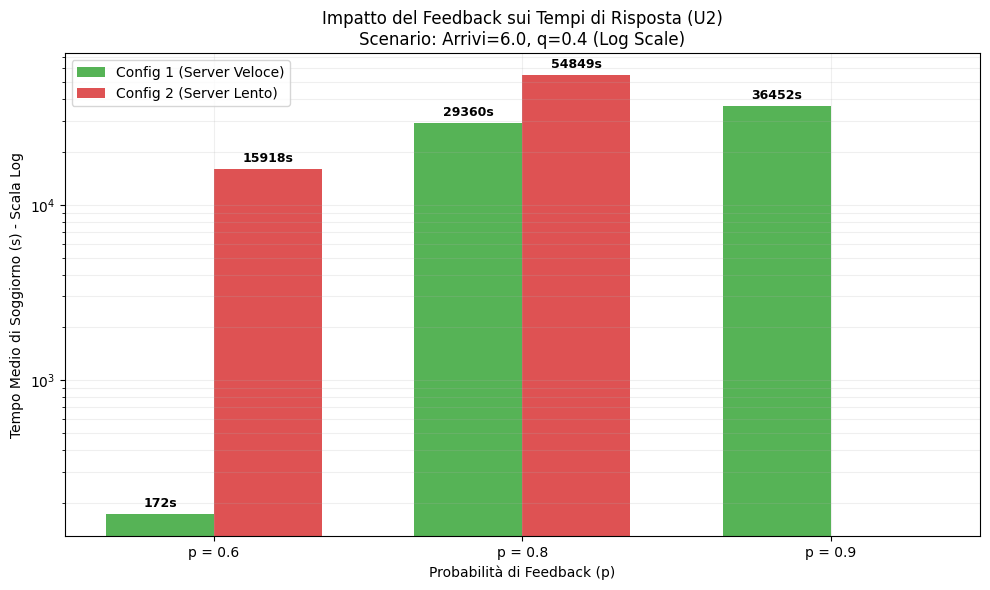

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# ==========================================
# 1. CARICAMENTO DATI
# ==========================================
# Imposta il nome del tuo file. Cerca la versione più recente.
possible_files = ['metrica2_stima_puntuale_2.csv', 'metrica2_stima_puntuale.csv']
file_path = next((f for f in possible_files if os.path.exists(f)), None)

if file_path is None:
    print("ERRORE: File CSV non trovato. Assicurati di aver caricato 'metrica2_stima_puntuale_2.csv'")
else:
    df = pd.read_csv(file_path)

    # ==========================================
    # 2. FILTRO DATI (SCENARIO DI CONFRONTO)
    # ==========================================
    # Fissiamo i parametri per un confronto "Ceteris Paribus"
    # m_arrivi=6.0 (Basso Carico), SS1=3.0, SS2=2.0, q=0.4
    scenario_mask = (
        (df['m_arrivi'] == 6.0) &
        (df['m_SS1'] == 3.0) &
        (df['m_SS2'] == 2.0) &
        (df['q_prob_U1'] == 0.4)
    )

    data = df[scenario_mask].copy()

    # Selezioniamo la colonna corretta per il Tempo Medio U2 (la vittima principale)
    # Cerca vari nomi possibili nel CSV
    col_target = None
    possible_cols = ['sojournTimeU2_stats_mean', 'sojournTimeU2:mean', 'Tempo_U2']
    for c in possible_cols:
        if c in data.columns:
            col_target = c
            break

    if col_target is None:
        # Fallback: se non trova la colonna, prova a usare la 2a colonna numerica
        # (Adatta questo indice se necessario)
        print("ATTENZIONE: Colonna 'sojournTimeU2' non trovata per nome. Uso fallback.")
        col_target = data.columns[-1]

    # ==========================================
    # 3. PREPARAZIONE DATI PER IL PLOT
    # ==========================================
    # Estraiamo i dati per Config 1 e Config 2 ordinati per p_feedback
    p_values = [0.6, 0.8, 0.9]

    y_config1 = []
    y_config2 = []

    for p in p_values:
        # Valore Config 1
        val1 = data[(data['Config'] == 'Config1') & (data['p_feedback'] == p)][col_target].values
        y_config1.append(val1[0] if len(val1) > 0 else 0)

        # Valore Config 2
        val2 = data[(data['Config'] == 'Config2') & (data['p_feedback'] == p)][col_target].values
        # Gestione NaN (es. saturazione totale)
        if len(val2) > 0:
            if pd.isna(val2[0]):
                y_config2.append(0) # O un valore fittizio per indicare "Infinity"
            else:
                y_config2.append(val2[0])
        else:
            y_config2.append(0)

    # ==========================================
    # 4. CREAZIONE GRAFICO
    # ==========================================
    plt.figure(figsize=(10, 6))

    # Posizioni delle barre
    x = np.arange(len(p_values))
    width = 0.35  # Larghezza barre

    # Plotting
    rects1 = plt.bar(x - width/2, y_config1, width, label='Config 1 (Server Veloce)', color='#2ca02c', alpha=0.8)
    rects2 = plt.bar(x + width/2, y_config2, width, label='Config 2 (Server Lento)', color='#d62728', alpha=0.8)

    # --- FORMATTAZIONE LOGARITMICA ---
    plt.yscale('log') # <--- IL TRUCCO MAGICO
    plt.ylabel('Tempo Medio di Soggiorno (s) - Scala Log')
    plt.title('Impatto del Feedback sui Tempi di Risposta (U2)\nScenario: Arrivi=6.0, q=0.4 (Log Scale)')
    plt.xticks(x, [f'p = {v}' for v in p_values])
    plt.xlabel('Probabilità di Feedback (p)')
    plt.legend()
    plt.grid(True, which="both", ls="-", alpha=0.2)

    # Funzione per etichette sopra le barre
    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            if height > 0:
                plt.annotate(f'{height:.0f}s',
                            xy=(rect.get_x() + rect.get_width() / 2, height),
                            xytext=(0, 3),  # 3 points vertical offset
                            textcoords="offset points",
                            ha='center', va='bottom', fontsize=9, fontweight='bold')
            else:
                # Se è 0 o NaN (Saturazione)
                plt.annotate('SATURATO\n(NaN)',
                            xy=(rect.get_x() + rect.get_width() / 2, 1), # Posiziona in basso
                            xytext=(0, 10),
                            textcoords="offset points",
                            ha='center', va='bottom', fontsize=8, color='red', rotation=90)

    autolabel(rects1)
    autolabel(rects2)

    plt.tight_layout()

    # Salvataggio
    output_filename = 'confronto_logaritmico_config1_vs_2.png'
    plt.savefig(output_filename)
    print(f"Grafico salvato come: {output_filename}")
    plt.show()

Grafico salvato come: confronto_coda_logaritmico.png


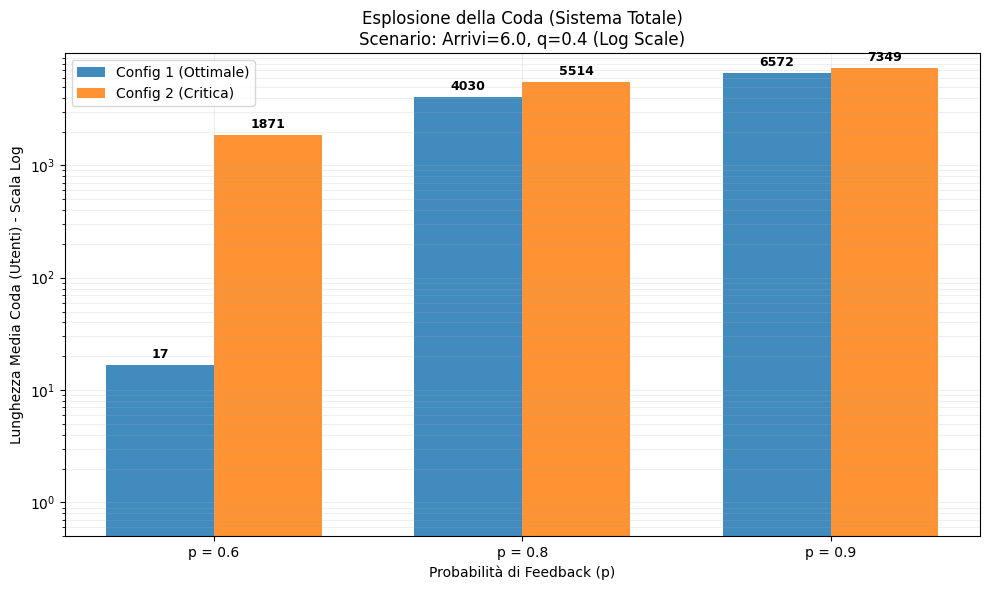

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# ==========================================
# 1. CARICAMENTO DATI (METRICA 1)
# ==========================================
file_name = 'metrica1_stima_puntuale.csv'

if not os.path.exists(file_name):
    print(f"ERRORE: File '{file_name}' non trovato.")
else:
    df = pd.read_csv(file_name)

    # ==========================================
    # 2. CALCOLO CODA TOTALE SISTEMA
    # ==========================================
    # Sommiamo le code del Nodo 1 e del Nodo 2 per avere la visione completa
    # Se le colonne totali non esistono, le calcoliamo dai componenti
    if 'CodaTotale_Nodo1' in df.columns and 'CodaTotale_Nodo2' in df.columns:
        df['CodaSistema'] = df['CodaTotale_Nodo1'] + df['CodaTotale_Nodo2']
    else:
        # Fallback somma manuale
        df['CodaSistema'] = (
            df.get('queueLenNode1_U1:timeavg', 0) +
            df.get('queueLenNode1_U2:timeavg', 0) +
            df.get('queueLenSS1:timeavg', 0) +
            df.get('queueLenSS2:timeavg', 0)
        )

    # ==========================================
    # 3. FILTRO DATI (SCENARIO DI CONFRONTO)
    # ==========================================
    # Scenario: Arrivi=6.0 (Basso Carico), SS1=3.0, SS2=2.0, q=0.4
    scenario_mask = (
        (df['m_arrivi'] == 6.0) &
        (df['m_SS1'] == 3.0) &
        (df['m_SS2'] == 2.0) &
        (df['q_prob_U1'] == 0.4)
    )

    data = df[scenario_mask].copy()

    # ==========================================
    # 4. PREPARAZIONE DATI PER IL PLOT
    # ==========================================
    p_values = [0.6, 0.8, 0.9]
    y_config1 = []
    y_config2 = []

    for p in p_values:
        # Config 1
        val1 = data[(data['Config'] == 'Config1') & (data['p_feedback'] == p)]['CodaSistema'].values
        y_config1.append(val1[0] if len(val1) > 0 else 0)

        # Config 2
        val2 = data[(data['Config'] == 'Config2') & (data['p_feedback'] == p)]['CodaSistema'].values
        if len(val2) > 0:
            y_config2.append(val2[0])
        else:
            y_config2.append(0) # 0 indica dato mancante

    # ==========================================
    # 5. CREAZIONE GRAFICO
    # ==========================================
    plt.figure(figsize=(10, 6))

    x = np.arange(len(p_values))
    width = 0.35

    # Plotting
    rects1 = plt.bar(x - width/2, y_config1, width, label='Config 1 (Ottimale)', color='#1f77b4', alpha=0.85)
    rects2 = plt.bar(x + width/2, y_config2, width, label='Config 2 (Critica)', color='#ff7f0e', alpha=0.85)

    # --- FORMATTAZIONE LOGARITMICA ---
    plt.yscale('log')
    plt.ylabel('Lunghezza Media Coda (Utenti) - Scala Log')
    plt.title('Esplosione della Coda (Sistema Totale)\nScenario: Arrivi=6.0, q=0.4 (Log Scale)')
    plt.xticks(x, [f'p = {v}' for v in p_values])
    plt.xlabel('Probabilità di Feedback (p)')
    plt.legend()
    plt.grid(True, which="both", ls="-", alpha=0.2)

    # Limite minimo asse Y per evitare barre invisibili se valore < 1
    plt.ylim(bottom=0.5)

    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            if height > 0:
                plt.annotate(f'{height:.0f}',
                            xy=(rect.get_x() + rect.get_width() / 2, height),
                            xytext=(0, 3),
                            textcoords="offset points",
                            ha='center', va='bottom', fontsize=9, fontweight='bold')
            else:
                plt.annotate('N/A',
                            xy=(rect.get_x() + rect.get_width() / 2, 1),
                            xytext=(0, 10),
                            textcoords="offset points",
                            ha='center', va='bottom', color='red')

    autolabel(rects1)
    autolabel(rects2)

    plt.tight_layout()
    output_filename = 'confronto_coda_logaritmico.png'
    plt.savefig(output_filename)
    print(f"Grafico salvato come: {output_filename}")
    plt.show()

Grafico salvato come: confronto_logaritmico_coda_U1.png


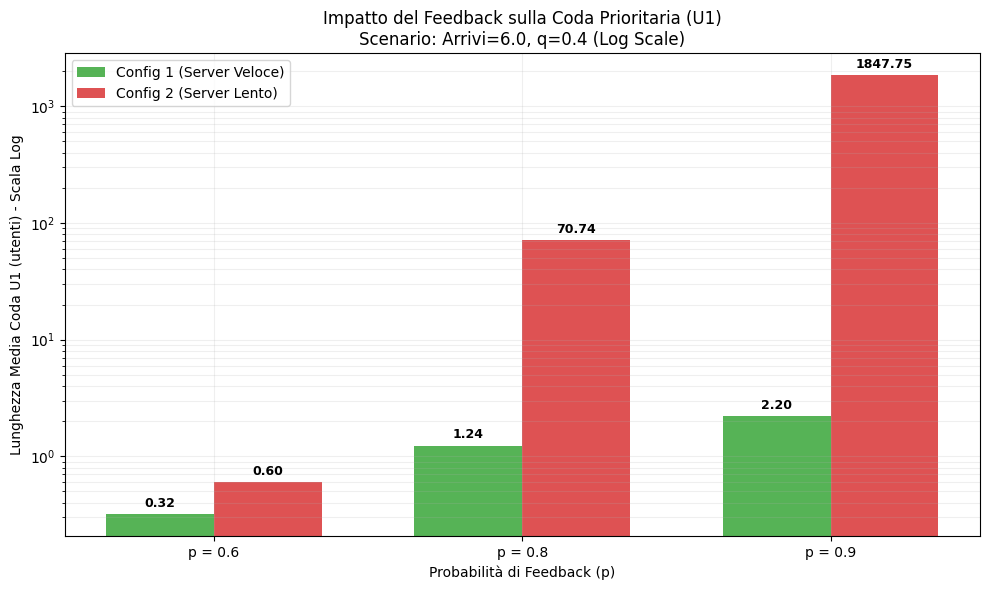

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# ==========================================
# 1. CARICAMENTO DATI (METRICA 1)
# ==========================================
file_name = 'metrica1_stima_puntuale.csv'

if not os.path.exists(file_name):
    print(f"ERRORE: File '{file_name}' non trovato.")
else:
    df = pd.read_csv(file_name)

    # ==========================================
    # 2. FILTRO DATI (SCENARIO DI CONFRONTO)
    # ==========================================
    # Fissiamo i parametri: Arrivi=6.0 (Basso Carico), SS1=3.0, SS2=2.0, q=0.4
    scenario_mask = (
        (df['m_arrivi'] == 6.0) &
        (df['m_SS1'] == 3.0) &
        (df['m_SS2'] == 2.0) &
        (df['q_prob_U1'] == 0.4)
    )

    data = df[scenario_mask].copy()

    # Colonna Target: Lunghezza Coda U1 al Nodo 1
    col_target = 'queueLenNode1_U1:timeavg'

    # ==========================================
    # 3. PREPARAZIONE DATI PER IL PLOT
    # ==========================================
    p_values = [0.6, 0.8, 0.9]

    y_config1 = []
    y_config2 = []

    for p in p_values:
        # Config 1
        val1 = data[(data['Config'] == 'Config1') & (data['p_feedback'] == p)][col_target].values
        y_config1.append(val1[0] if len(val1) > 0 else 0)

        # Config 2
        val2 = data[(data['Config'] == 'Config2') & (data['p_feedback'] == p)][col_target].values
        y_config2.append(val2[0] if len(val2) > 0 else 0)

    # ==========================================
    # 4. CREAZIONE GRAFICO
    # ==========================================
    plt.figure(figsize=(10, 6))

    x = np.arange(len(p_values))
    width = 0.35

    # Barre
    rects1 = plt.bar(x - width/2, y_config1, width, label='Config 1 (Server Veloce)', color='#2ca02c', alpha=0.8)
    rects2 = plt.bar(x + width/2, y_config2, width, label='Config 2 (Server Lento)', color='#d62728', alpha=0.8)

    # --- FORMATTAZIONE LOGARITMICA ---
    plt.yscale('log')
    plt.ylabel('Lunghezza Media Coda U1 (utenti) - Scala Log')
    plt.title('Impatto del Feedback sulla Coda Prioritaria (U1)\nScenario: Arrivi=6.0, q=0.4 (Log Scale)')
    plt.xticks(x, [f'p = {v}' for v in p_values])
    plt.xlabel('Probabilità di Feedback (p)')
    plt.legend()
    plt.grid(True, which="both", ls="-", alpha=0.2)

    # Etichette valori
    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            if height > 0:
                # Formattazione con 2 decimali essendo numeri piccoli
                plt.annotate(f'{height:.2f}',
                            xy=(rect.get_x() + rect.get_width() / 2, height),
                            xytext=(0, 3),
                            textcoords="offset points",
                            ha='center', va='bottom', fontsize=9, fontweight='bold')
            else:
                plt.annotate('0',
                            xy=(rect.get_x() + rect.get_width() / 2, 0),
                            xytext=(0, 3), textcoords="offset points", ha='center')

    autolabel(rects1)
    autolabel(rects2)

    plt.tight_layout()

    output_filename = 'confronto_logaritmico_coda_U1.png'
    plt.savefig(output_filename)
    print(f"Grafico salvato come: {output_filename}")
    plt.show()

Grafico salvato come: confronto_coda_U1_log.png


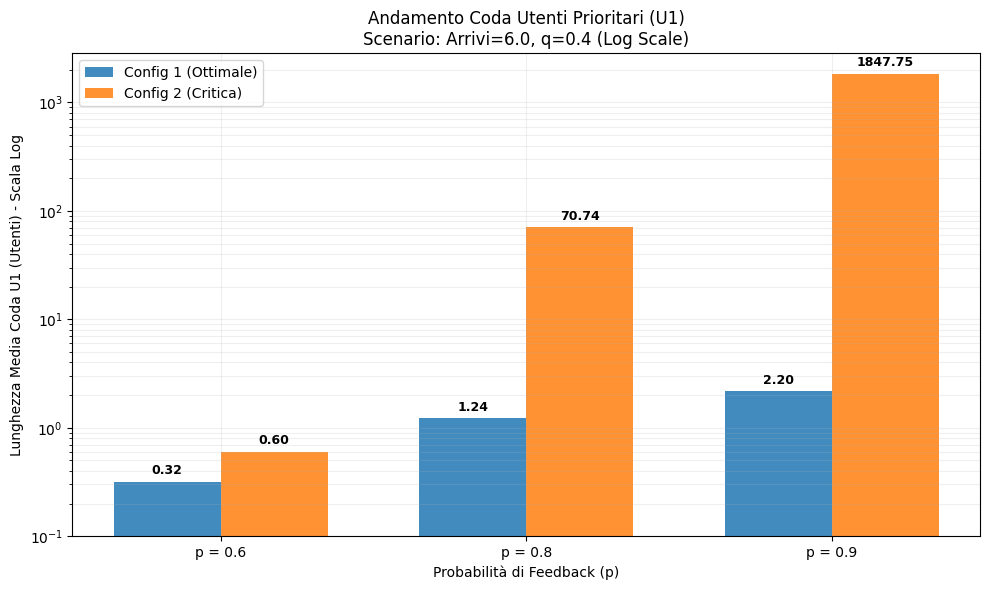

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# ==========================================
# 1. CARICAMENTO DATI (METRICA 1)
# ==========================================
file_name = 'metrica1_stima_puntuale.csv'

if not os.path.exists(file_name):
    print(f"ERRORE: File '{file_name}' non trovato.")
else:
    df = pd.read_csv(file_name)

    # ==========================================
    # 2. SELEZIONE COLONNA TARGET (U1)
    # ==========================================
    # Ci concentriamo sulla coda specifica degli utenti U1 al Nodo 1 (dove hanno priorità)
    target_col = 'queueLenNode1_U1:timeavg'

    # Verifica esistenza colonna
    if target_col not in df.columns:
        print(f"ATTENZIONE: Colonna '{target_col}' non trovata. Cerco alternative...")
        # Fallback nel caso il nome sia leggermente diverso
        alternatives = [c for c in df.columns if 'U1' in c and 'queue' in c]
        if alternatives:
            target_col = alternatives[0]
            print(f"Usata colonna alternativa: {target_col}")

    # ==========================================
    # 3. FILTRO DATI (SCENARIO DI CONFRONTO)
    # ==========================================
    # Scenario: Arrivi=6.0 (Basso Carico), SS1=3.0, SS2=2.0, q=0.4
    scenario_mask = (
        (df['m_arrivi'] == 6.0) &
        (df['m_SS1'] == 3.0) &
        (df['m_SS2'] == 2.0) &
        (df['q_prob_U1'] == 0.4)
    )

    data = df[scenario_mask].copy()

    # ==========================================
    # 4. PREPARAZIONE DATI PER IL PLOT
    # ==========================================
    p_values = [0.6, 0.8, 0.9]
    y_config1 = []
    y_config2 = []

    for p in p_values:
        # Config 1
        val1 = data[(data['Config'] == 'Config1') & (data['p_feedback'] == p)][target_col].values
        y_config1.append(val1[0] if len(val1) > 0 else 0)

        # Config 2
        val2 = data[(data['Config'] == 'Config2') & (data['p_feedback'] == p)][target_col].values
        if len(val2) > 0:
            y_config2.append(val2[0])
        else:
            y_config2.append(0) # 0 indica dato mancante

    # ==========================================
    # 5. CREAZIONE GRAFICO
    # ==========================================
    plt.figure(figsize=(10, 6))

    x = np.arange(len(p_values))
    width = 0.35

    # Plotting
    rects1 = plt.bar(x - width/2, y_config1, width, label='Config 1 (Ottimale)', color='#1f77b4', alpha=0.85)
    rects2 = plt.bar(x + width/2, y_config2, width, label='Config 2 (Critica)', color='#ff7f0e', alpha=0.85)

    # --- FORMATTAZIONE LOGARITMICA ---
    plt.yscale('log')
    plt.ylabel('Lunghezza Media Coda U1 (Utenti) - Scala Log')
    plt.title('Andamento Coda Utenti Prioritari (U1)\nScenario: Arrivi=6.0, q=0.4 (Log Scale)')
    plt.xticks(x, [f'p = {v}' for v in p_values])
    plt.xlabel('Probabilità di Feedback (p)')
    plt.legend()
    plt.grid(True, which="both", ls="-", alpha=0.2)

    # Limite minimo asse Y ottimizzato per valori piccoli (U1)
    # Impostiamo un minimo basso (es. 0.1) per vedere anche le code molto corte in log scale
    plt.ylim(bottom=0.1)

    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            if height > 0:
                # Usiamo 2 decimali (.2f) perché la coda U1 è spesso piccola (es. 0.32)
                plt.annotate(f'{height:.2f}',
                            xy=(rect.get_x() + rect.get_width() / 2, height),
                            xytext=(0, 3),
                            textcoords="offset points",
                            ha='center', va='bottom', fontsize=9, fontweight='bold')
            else:
                plt.annotate('N/A',
                            xy=(rect.get_x() + rect.get_width() / 2, 0.1),
                            xytext=(0, 10),
                            textcoords="offset points",
                            ha='center', va='bottom', color='red')

    autolabel(rects1)
    autolabel(rects2)

    plt.tight_layout()
    output_filename = 'confronto_coda_U1_log.png'
    plt.savefig(output_filename)
    print(f"Grafico salvato come: {output_filename}")
    plt.show()

Tutti i file caricati correttamante.

 TABELLA METRICA 1 PULITA (con Errore Relativo e Aggregazione)
 Scenario: m_arrivi=6.0, SS1=3.0, SS2=2.0
Scenario                                 | N1_U1    | N1_U2      | N2_Tot     | Tot_Sys    | Err %    | Qualità    | Note
------------------------------------------------------------------------------------------------------------------------
Config1 p=0.6 q=0.4                      | 0.3190   | 16.0282    | 0.1987     | 16.5       | 28.0%    | CRITICO    | 
Config1 p=0.8 q=0.4                      | 1.2359   | 4026.0241  | 2.9588     | 4030.2     | 1.0%     | Ottimo     | SATURAZIONE
Config1 p=0.9 q=0.4                      | 2.1988   | 5080.6257  | 1488.8740  | 6571.7     | 0.6%     | Ottimo     | SATURAZIONE
Config1 p=0.6 q=0.6                      | 0.5969   | 6.3870     | 0.3552     | 7.3        | 7.9%     | Buono      | 
Config1 p=0.8 q=0.6                      | 3.5152   | 3061.5675  | 725.7345   | 3790.8     | 0.8%     | Ottimo     | SAT

In [16]:
import pandas as pd
import numpy as np
import os

# ==========================================
# 1. CARICAMENTO DATI (METRICA 2)
# ==========================================
# Sostituisci con i nomi esatti dei tuoi file se diversi
files = {
    'mean': 'metrica2_stima_puntuale_2.csv',  # O 'metrica2_stima_puntuale.csv'
    'low': 'metrica2_ci_inferiore_2.csv',     # Assicurati di averlo caricato
    'high': 'metrica2_ci_superiore_2.csv'     # Assicurati di averlo caricato
}

# Controllo esistenza
if not all(os.path.exists(f) for f in files.values()):
    print("ATTENZIONE: Mancano i file CSV completi per la Metrica 2.")
    print("Lo script tenterà di usare solo la media se mancano i CI.")
    df = pd.read_csv(files['mean']) if os.path.exists(files['mean']) else pd.DataFrame()
    df_l = pd.DataFrame()
    df_h = pd.DataFrame()
else:
    df = pd.read_csv(files['mean'])
    df_l = pd.read_csv(files['low'])
    df_h = pd.read_csv(files['high'])

# ==========================================
# 2. FUNZIONE PULIZIA E CALCOLO ERRORE
# ==========================================
def genera_tabella_metrica2(df, df_l, df_h):
    results = []

    # Cerchiamo le colonne corrette (gestione nomi diversi)
    col_u1 = next((c for c in df.columns if 'U1' in c and ('mean' in c or 'Tempo' in c)), None)
    col_u2 = next((c for c in df.columns if 'U2' in c and ('mean' in c or 'Tempo' in c)), None)

    if not col_u1 or not col_u2:
        return pd.DataFrame() # Esce se non trova colonne

    # Colonne per matching righe
    cols_match = ['Config', 'm_arrivi', 'p_feedback', 'm_SS1', 'm_SS2', 'q_prob_U1']

    for idx, row in df.iterrows():
        t_u1 = row[col_u1]
        t_u2 = row[col_u2]

        # Calcolo Errore Relativo su U2 (la vittima principale)
        err_rel = np.nan
        err_label = "N/A"

        if not df_l.empty and not pd.isna(t_u2):
            mask = pd.Series([True] * len(df_l))
            for c in cols_match:
                mask = mask & (df_l[c] == row[c])

            if mask.sum() > 0:
                idx_ci = df_l[mask].index[0]
                # Verifica se la colonna esiste nel CI
                if col_u2 in df_l.columns:
                    val_low = df_l.loc[idx_ci, col_u2]
                    val_high = df_h.loc[idx_ci, col_u2]

                    if not pd.isna(val_low) and not pd.isna(val_high) and t_u2 > 0.001:
                        # FORMULA: Err% = Semiopiezza / Media * 100
                        semi_amp = (val_high - val_low) / 2
                        err_rel = (semi_amp / t_u2) * 100

                        if err_rel < 5: err_label = "Ottimo"
                        elif err_rel < 10: err_label = "Buono"
                        elif err_rel < 20: err_label = "Instabile"
                        else: err_label = "CRITICO"

        # Note automatiche
        note = ""
        if pd.isna(t_u2): note = "SATURAZIONE (NaN)"
        elif t_u2 > 10000: note = "SATURAZIONE (>10ks)"
        elif t_u2 > t_u1 * 10: note = "Disparità Estrema"

        results.append({
            'Scenario': f"{row['Config']} p={row['p_feedback']} q={row['q_prob_U1']}",
            'Tempo_U1': t_u1,
            'Tempo_U2': t_u2,
            'Err_U2 %': f"{err_rel:.1f}%" if not np.isnan(err_rel) else "-",
            'Qualità': err_label,
            'Note': note
        })

    return pd.DataFrame(results)

# ==========================================
# 3. FILTRO E STAMPA
# ==========================================
if not df.empty:
    # Filtro Scenario: m=6.0, SS1=3.0, SS2=2.0 (Analisi Sensibilità)
    mask_scenario = (
        (df['m_arrivi'] == 6.0) &
        (df['m_SS1'] == 3.0) &
        (df['m_SS2'] == 2.0)
    )

    df_clean = genera_tabella_metrica2(df[mask_scenario], df_l, df_h)

    print("\n" + "="*120)
    print(" TABELLA METRICA 2 PULITA (Tempi di Soggiorno con Errore Relativo)")
    print(" Scenario: m_arrivi=6.0, SS1=3.0, SS2=2.0")
    print("="*120)

    print(f"{'Scenario':<40} | {'Tempo U1':<12} | {'Tempo U2':<12} | {'Err U2 %':<10} | {'Qualità':<10} | {'Note'}")
    print("-" * 120)

    for _, row in df_clean.iterrows():
        # Formattazione NaN safe
        t1 = f"{row['Tempo_U1']:.1f}" if not pd.isna(row['Tempo_U1']) else "NaN"
        t2 = f"{row['Tempo_U2']:.1f}" if not pd.isna(row['Tempo_U2']) else "NaN"

        print(f"{row['Scenario']:<40} | {t1:<12} | {t2:<12} | {row['Err_U2 %']:<10} | {row['Qualità']:<10} | {row['Note']}")

    print("-" * 120)


 TABELLA METRICA 2 PULITA (Tempi di Soggiorno con Errore Relativo)
 Scenario: m_arrivi=6.0, SS1=3.0, SS2=2.0
Scenario                                 | Tempo U1     | Tempo U2     | Err U2 %   | Qualità    | Note
------------------------------------------------------------------------------------------------------------------------
Config1 p=0.6 q=0.4                      | 16.1         | 171.8        | 26.4%      | CRITICO    | Disparità Estrema
Config1 p=0.8 q=0.4                      | 84.2         | 29359.6      | 1.0%       | Ottimo     | SATURAZIONE (>10ks)
Config1 p=0.9 q=0.4                      | 15113.1      | 36452.2      | 1.1%       | Ottimo     | SATURAZIONE (>10ks)
Config1 p=0.6 q=0.6                      | 18.6         | 106.1        | 7.4%       | Buono      | 
Config1 p=0.8 q=0.6                      | 6195.7       | 34782.7      | 1.1%       | Ottimo     | SATURAZIONE (>10ks)
Config1 p=0.9 q=0.6                      | 18075.1      | 36182.0      | 1.4%       | Ottim